# Project 3: Trapped in a Low Dimension (Fixed)
## Exploring Neural Population Dynamics through Dimensionality Reduction
### MICrONS Dataset — Mouse Visual Cortex (V1)

**Course:** Neuroscience Computation  
**Dataset:** MICrONS Functional + Structural Connectomics (version 1718)  
**Session analysed:** `9_4`

### Fixes over previous versions
| Issue | Previous | Fixed here |
|---|---|---|
| Neuron mismatch | 7,855 unfiltered neurons | 728 trusted neurons matched via unit_ids |
| Class imbalance | Standard accuracy (broken) | Balanced accuracy + macro F1 |
| Axis units | nm (wrong) | µm (correct) |
| CEBRA undefined error | Crashed comparison cell | R_cebra initialised to None |
| Neuron-space metadata | 728/7855 rows labelled 'unknown' | Metadata aligned to matched unit IDs |
| Shuffle control | Locked at 0.857, p=1.0 | Balanced accuracy, informative null |

> **Note:** If you get a 403 FORBIDDEN / missing_tos error on first run, accept the MICrONS Terms of Service at https://global.daf-apis.com/sticky_auth/api/v1/tos/2/accept then re-run.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
import seaborn as sns
from collections import defaultdict, Counter
import warnings
import h5py
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (silhouette_score, balanced_accuracy_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from scipy.stats import ttest_1samp

try:
    import umap
    UMAP_AVAILABLE = True
    print("UMAP   ✓")
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP   ✗  pip install umap-learn")

try:
    import cebra
    CEBRA_AVAILABLE = True
    print("CEBRA  ✓")
except ImportError:
    CEBRA_AVAILABLE = False
    print("CEBRA  ✗  pip install cebra (optional)")

%load_ext autoreload
%autoreload 2
import microns_datacleaner as mic
import microns_datacleaner.filters as fl

print("\nAll imports successful ✓")

UMAP   ✓
CEBRA  ✓

All imports successful ✓


In [2]:
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 12, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False, 'savefig.bbox': 'tight',
})
SEED = 42
SESSION = '9_4'

## 1. Load Metadata and Filter to Trusted Neurons

In [3]:
cleaner = mic.MicronsDataCleaner(datadir='data/', version=1718)
cleaner.download_nucleus_data()

units, segments = cleaner.process_nucleus_data(functional_data='best_only')
print(f"Total units loaded: {len(units)}")

# Filter to high-quality V1 neurons: proofread axon + matched tuning
v1_neurons = fl.filter_neurons(units, brain_area='V1',
                               proofread='ax_clean', tuning='matched')

v1_exc = v1_neurons[v1_neurons['classification_system'] == 'excitatory_neuron']
v1_inh = v1_neurons[v1_neurons['classification_system'] == 'inhibitory_neuron']

print(f"\nV1 neurons (proofread + matched tuning): {len(v1_neurons)}")
print(f"  Excitatory : {len(v1_exc)}")
print(f"  Inhibitory : {len(v1_inh)}")

if len(v1_inh) == 0:
    print("  NOTE: 0 inhibitory neurons — the 'ax_clean' proofread filter")
    print("  removes most inhibitory cells (their axons are harder to reconstruct).")
    print("  Consider proofread='dendrite_clean' or no proofread filter for inhibitory analysis.")

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 60485.42it/s]


Total units loaded: 90434

V1 neurons (proofread + matched tuning): 728
  Excitatory : 728
  Inhibitory : 0
  NOTE: 0 inhibitory neurons — the 'ax_clean' proofread filter
  removes most inhibitory cells (their axons are harder to reconstruct).
  Consider proofread='dendrite_clean' or no proofread filter for inhibitory analysis.


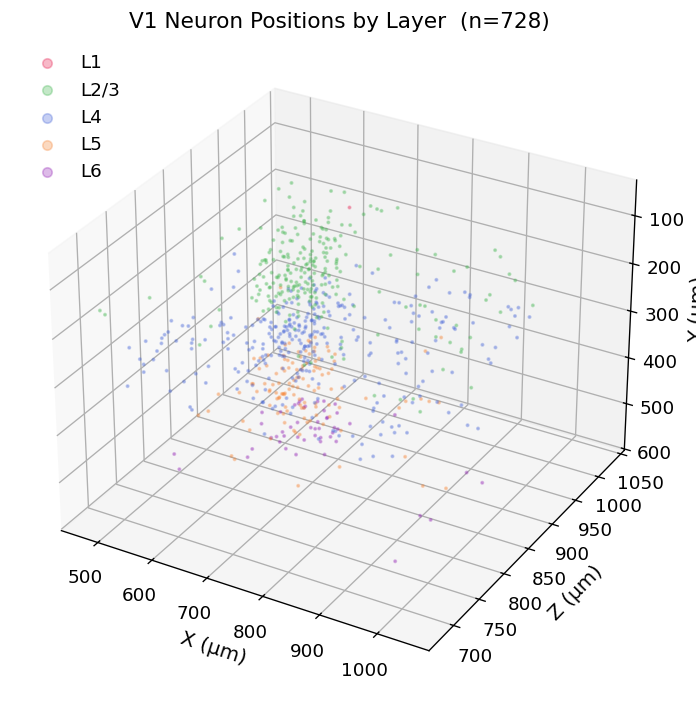

In [4]:
# 3D spatial map of neurons by layer
# FIX: axis labels corrected from nm to µm
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(projection='3d')
ax.zaxis.set_inverted(True)

LAYER_COLORS = {
    'L1': '#e6194b', 'L2/3': '#3cb44b',
    'L4': '#4363d8', 'L5': '#f58231', 'L6': '#911eb4'
}

for layer, color in LAYER_COLORS.items():
    ul = fl.filter_neurons(v1_neurons, layer=layer)
    if len(ul):
        ax.scatter(ul['pt_position_x'], ul['pt_position_z'], ul['pt_position_y'],
                   alpha=0.3, s=2, color=color, label=layer)

# FIX: correct units are µm not nm
ax.set_xlabel('X (µm)'); ax.set_ylabel('Z (µm)'); ax.set_zlabel('Y (µm)')
ax.set_title(f'V1 Neuron Positions by Layer  (n={len(v1_neurons)})')
ax.legend(markerscale=4, loc='upper left')
plt.tight_layout(); plt.show()

## 2. KEY FIX: Match Functional Recording Columns to Trusted Neurons

**The problem in previous versions:** `MicronsFunctionalReader.get_trial()` returns responses for all 7,855 neurons recorded in the session. The quality-filtered 728 neurons were never cross-referenced against these 7,855 columns — the DR analysis ran on all unfiltered neurons.

**The fix:** The h5 file stores `unit_ids` for every column in `r['responses']`. We read those IDs, cross-reference with the trusted neuron IDs from `v1_neurons`, and keep only the matching columns.

In [6]:
# Read the ordered unit_ids from the h5 file
# session_unit_ids[i] is the unit_id for column i of r['responses']
with h5py.File('microns.h5', 'r') as f:
    session_unit_ids = f['sessions'][SESSION]['meta']['unit_ids'][:]

print(f"Columns in r['responses']   : {len(session_unit_ids)}")
print(f"Sample unit_ids             : {session_unit_ids[:5]}")

# Get the unit_ids of our trusted filtered neurons
v1_with_uid = v1_neurons.dropna(subset=['unit_id']).copy()
v1_with_uid['unit_id_int'] = v1_with_uid['unit_id'].astype(int)
trusted_unit_ids = set(v1_with_uid['unit_id_int'].values)

print(f"\nTrusted filtered neuron IDs : {len(trusted_unit_ids)}")

# Find which column indices correspond to our trusted neurons
keep_neuron_cols = np.where(np.isin(session_unit_ids, list(trusted_unit_ids)))[0]
print(f"Overlap (trusted in session): {len(keep_neuron_cols)}")
print(f"Columns dropped (unverified): {len(session_unit_ids) - len(keep_neuron_cols)}")

# Deduplicate and index — use .at for guaranteed scalar access
uid_to_meta = v1_with_uid.drop_duplicates(subset=['unit_id_int']).set_index('unit_id_int')

def get_meta_val(uid, col):
    if uid in uid_to_meta.index:
        val = uid_to_meta.at[uid, col]
        return str(val) if not isinstance(val, str) else val
    return 'unknown'

trusted_meta = pd.DataFrame([
    {
        'unit_id': int(uid),
        'layer': get_meta_val(uid, 'layer'),
        'classification_system': get_meta_val(uid, 'classification_system'),
    }
    for uid in session_unit_ids[keep_neuron_cols]
])

n_known = (trusted_meta['layer'] != 'unknown').sum()
print(f"\nMetadata aligned for {n_known} / {len(trusted_meta)} neurons")
print(f"Layer distribution:\n{trusted_meta['layer'].value_counts().to_string()}")


Columns in r['responses']   : 7855
Sample unit_ids             : [1 3 4 5 6]

Trusted filtered neuron IDs : 698
Overlap (trusted in session): 579
Columns dropped (unverified): 7276

Metadata aligned for 579 / 579 neurons
Layer distribution:
layer
L4      257
L2/3    220
L5       89
L6       12
L1        1


## 3. Build Population Response Matrix (Trusted Neurons Only)

In [ ]:
funcreader = mic.MicronsFunctionalReader(path='microns.h5')
hashes = funcreader.get_hashes_by_session(SESSION)

stim_types = [funcreader.get_video_type(h) for h in hashes]
type_counts = Counter(stim_types)

print(f"Total trials in session {SESSION}: {len(hashes)}")
print("\nStimulus types (raw trials):")
for k, v in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {k:22s}: {v:4d} trials")

In [ ]:
# Collect per-trial mean responses — ONLY for trusted neurons
hash_to_responses = defaultdict(list)
hash_to_type      = {}
n_failed = 0

print("Loading trial responses (trusted neurons only)...")
for trial_idx, h in enumerate(hashes):
    hash_to_type[h] = funcreader.get_video_type(h)
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed += 1
            continue
        # FIX: slice to keep_neuron_cols — only trusted verified neurons
        mean_resp = r['responses'][keep_neuron_cols, :].mean(axis=1)
        hash_to_responses[h].append(mean_resp)
    except Exception:
        n_failed += 1

print(f"  Done. {len(hash_to_responses)} unique stimuli | {n_failed} trials skipped")

# Average across repeated presentations
unique_hashes = sorted(hash_to_responses.keys())
R_matrix  = np.array([np.mean(hash_to_responses[h], axis=0) for h in unique_hashes])
labels_raw = np.array([hash_to_type[h] for h in unique_hashes])

print(f"\nResponse matrix shape: {R_matrix.shape}")
print(f"  rows = unique stimuli,  cols = trusted neurons")
print("\nStimulus distribution (unique stimuli):")
for lbl, cnt in Counter(labels_raw).items():
    print(f"  {lbl:22s}: {cnt}")

## 4. Preprocessing

In [ ]:
# 1. Drop high-NaN neurons
nan_frac     = np.isnan(R_matrix).mean(axis=0)
keep_neurons = nan_frac < 0.10
R_clean      = R_matrix[:, keep_neurons].copy()
print(f"Neurons after NaN filter  : {keep_neurons.sum()} / {R_matrix.shape[1]}")

# Update trusted_meta to match
trusted_meta_clean = trusted_meta[keep_neurons].reset_index(drop=True)

# 2. Impute remaining NaNs
col_means = np.nanmean(R_clean, axis=0)
nan_idx   = np.where(np.isnan(R_clean))
R_clean[nan_idx] = np.take(col_means, nan_idx[1])

# 3. Drop near-silent stimuli
active  = R_clean.std(axis=1) > 1e-6
R_clean = R_clean[active]
labels  = labels_raw[active]
print(f"Stimuli after activity filter: {active.sum()} / {R_matrix.shape[0]}")

# 4. Z-score
scaler   = StandardScaler()
R_scaled = scaler.fit_transform(R_clean)

print(f"\nFinal matrix: {R_scaled.shape}  (stimuli x trusted neurons)")
print(f"  Mean: {R_scaled.mean():+.4f}  Std: {R_scaled.std():+.4f}")

In [ ]:
# Class balance analysis
unique_labels  = sorted(set(labels))
n_types        = len(unique_labels)
palette        = plt.cm.get_cmap('tab10', n_types)
label_to_color = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
le             = LabelEncoder()
y              = le.fit_transform(labels)
counts         = {lbl: int(np.sum(labels == lbl)) for lbl in unique_labels}
majority_frac  = max(counts.values()) / len(labels)
chance_level   = 1.0 / n_types
legend_patches = [Patch(color=label_to_color[l], label=l) for l in unique_labels]

print("Stimulus distribution:")
for lbl, n in counts.items():
    print(f"  {lbl:22s}  n={n:4d}  ({100*n/len(labels):.1f}%)")
print(f"\nMajority-class baseline (always predict Clip): {majority_frac:.3f}")
print(f"Balanced-accuracy chance level (1/k)         : {chance_level:.3f}")
print("=> Using balanced accuracy + macro F1 as primary metrics throughout.")

# Balanced subsample: 20 per class
rng_bal = np.random.default_rng(seed=SEED)
N_BAL   = int(min(counts.values()))
bal_idx = np.sort(np.concatenate([
    rng_bal.choice(np.where(labels == lbl)[0], size=N_BAL, replace=False)
    for lbl in unique_labels
]))
y_bal      = y[bal_idx]
labels_bal = labels[bal_idx]
R_bal      = R_scaled[bal_idx]

print(f"\nBalanced subsample: {N_BAL} per class × {n_types} = {len(bal_idx)} total")

# Shared balanced classifier + CV
cv_bal  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf_bal = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED,
                              class_weight='balanced')

# Class balance bar chart
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(list(counts.keys()), list(counts.values()),
              color=[label_to_color[l] for l in counts], edgecolor='white')
ax.axhline(len(labels) / n_types, color='red', ls='--',
           label=f'Balanced target (n={len(labels)//n_types})')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of stimuli')
ax.set_title('Class Distribution')
ax.legend(); plt.tight_layout()
plt.savefig('fig_class_balance.png', dpi=150); plt.show()

## 5. Dimensionality Reduction

### 5a. PCA

In [ ]:
n_pcs = min(150, R_scaled.shape[0] - 1, R_scaled.shape[1] - 1)
pca   = PCA(n_components=n_pcs, random_state=SEED)
R_pca = pca.fit_transform(R_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
ev     = pca.explained_variance_ratio_
participation_ratio = 1.0 / np.sum(ev ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, n_pcs + 1), cumvar * 100, '-', lw=1.5, color='steelblue')
axes[0].axhline(80, color='red',    ls='--', alpha=0.8, label='80%')
axes[0].axhline(90, color='orange', ls='--', alpha=0.8, label='90%')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative variance (%)')
axes[0].set_title('Cumulative Variance'); axes[0].legend(); axes[0].set_xlim(0, n_pcs)

axes[1].bar(np.arange(1, 31), ev[:30] * 100, color='steelblue', edgecolor='white')
axes[1].set_xlabel('PC'); axes[1].set_ylabel('Variance (%)')
axes[1].set_title('Scree Plot (first 30 PCs)')

plt.suptitle('PCA — Intrinsic Dimensionality', fontsize=13)
plt.tight_layout()
plt.savefig('fig_pca_variance.png', dpi=150); plt.show()

n80 = min(int(np.searchsorted(cumvar, 0.80)) + 1, n_pcs)
n90 = min(int(np.searchsorted(cumvar, 0.90)) + 1, n_pcs)
print(f"PCs for 80% variance      : {n80}")
print(f"PCs for 90% variance      : {n90}")
print(f"Variance in PC1           : {ev[0]*100:.2f}%")
print(f"Variance in PC1+PC2       : {cumvar[1]*100:.2f}%")
print(f"Variance in PC1-PC10      : {cumvar[9]*100:.2f}%")
print(f"Participation ratio (eff dim): {participation_ratio:.1f}")

In [ ]:
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    scale_x = np.sqrt(cov[0,0]) * n_std
    scale_y = np.sqrt(cov[1,1]) * n_std
    ellipse = Ellipse((0,0), width=rx*2, height=ry*2, **kwargs)
    t = (transforms.Affine2D().rotate_deg(45)
         .scale(scale_x, scale_y).translate(x.mean(), y.mean()))
    ellipse.set_transform(t + ax.transData)
    return ax.add_patch(ellipse)

fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

for col, (xi, yi, title) in enumerate([
        (0, 1, f'PC1 vs PC2'),
        (0, 2, f'PC1 vs PC3'),
        (None, None, 'PCA 3D')]):
    if col < 2:
        ax = fig.add_subplot(gs[col])
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_pca[m,xi], R_pca[m,yi], color=label_to_color[lbl],
                       alpha=0.6, s=22, edgecolors='none', label=lbl)
            confidence_ellipse(R_pca[m,xi], R_pca[m,yi], ax, n_std=2,
                               edgecolor=label_to_color[lbl], facecolor='none',
                               lw=1.5, ls='--', alpha=0.8)
        ax.set_xlabel(f'PC{xi+1} ({ev[xi]*100:.1f}%)')
        ax.set_ylabel(f'PC{yi+1} ({ev[yi]*100:.1f}%)')
        ax.set_title(title)
    else:
        ax = fig.add_subplot(gs[2], projection='3d')
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_pca[m,0], R_pca[m,1], R_pca[m,2],
                       color=label_to_color[lbl], alpha=0.6, s=15)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
        ax.set_title('PCA 3D')

fig.legend(handles=legend_patches, loc='lower center', ncol=n_types,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('PCA Projections — 2-sigma confidence ellipses', fontsize=13, y=1.02)
plt.savefig('fig_pca_scatter.png', dpi=150); plt.show()

### 5b. t-SNE

In [ ]:
n_pca_for_tsne = min(50, n_pcs)
tsne_results   = {}
PERPLEXITIES   = [15, 30, 50]

print("Running t-SNE (3 perplexity values)...")
for perp in PERPLEXITIES:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=SEED,
                max_iter=1000, learning_rate='auto', init='pca')
    tsne_results[perp] = tsne.fit_transform(R_pca[:, :n_pca_for_tsne])
    print(f"  perplexity={perp}  ✓")

R_tsne = tsne_results[30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, perp in zip(axes, PERPLEXITIES):
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(tsne_results[perp][m,0], tsne_results[perp][m,1],
                   color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
    ax.set_title(f't-SNE  perplexity={perp}')
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
plt.suptitle('t-SNE — Perplexity Sensitivity', fontsize=13)
plt.tight_layout()
plt.savefig('fig_tsne_perplexity.png', dpi=150); plt.show()

### 5c. UMAP

In [ ]:
R_umap = None
if UMAP_AVAILABLE:
    umap_results = {}
    N_NEIGHBORS_LIST = [5, 15, 50]
    print("Running UMAP (3 n_neighbors values)...")
    for nn in N_NEIGHBORS_LIST:
        reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                            metric='euclidean', random_state=SEED)
        umap_results[nn] = reducer.fit_transform(R_pca[:, :n_pca_for_tsne])
        print(f"  n_neighbors={nn}  ✓")
    R_umap = umap_results[15]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, nn in zip(axes, N_NEIGHBORS_LIST):
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(umap_results[nn][m,0], umap_results[nn][m,1],
                       color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
        ax.set_title(f'UMAP  n_neighbors={nn}')
        ax.set_xticks([]); ax.set_yticks([])
    axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.suptitle('UMAP — n_neighbors Sensitivity', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_umap_neighbors.png', dpi=150); plt.show()

### 5d. CEBRA (optional)

In [ ]:
# FIX: initialise R_cebra = None BEFORE trying CEBRA
# so the comparison cell below never crashes with NameError
R_cebra = None

if CEBRA_AVAILABLE:
    try:
        import torch
        label_cont = y.astype(np.float32).reshape(-1, 1)
        cb_model = cebra.CEBRA(
            model_architecture='offset10-model',
            batch_size=min(512, len(R_scaled)//2),
            learning_rate=3e-4,
            temperature=1.0,
            output_dimension=8,
            max_iterations=2000,
            device='cpu',
            verbose=True,
        )
        cb_model.fit(R_scaled.astype(np.float32), label_cont)
        R_cebra = cb_model.transform(R_scaled.astype(np.float32))

        fig, ax = plt.subplots(figsize=(6,5))
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_cebra[m,0], R_cebra[m,1], color=label_to_color[lbl],
                       alpha=0.7, s=25, label=lbl)
        ax.set_title('CEBRA Embedding (supervised)')
        ax.set_xlabel('Dim-1'); ax.set_ylabel('Dim-2')
        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.savefig('fig_cebra.png', dpi=150); plt.show()
    except Exception as e:
        print(f"CEBRA failed: {e}")
        R_cebra = None
else:
    print("CEBRA not installed — pip install cebra")

## 6. Side-by-Side Comparison

In [ ]:
methods = [('PCA', R_pca[:, :2]), ('t-SNE (perp=30)', R_tsne)]
if UMAP_AVAILABLE  and R_umap  is not None: methods.append(('UMAP (nn=15)',  R_umap))
if CEBRA_AVAILABLE and R_cebra is not None: methods.append(('CEBRA', R_cebra[:, :2]))

fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4.5))
if len(methods) == 1: axes = [axes]

for ax, (name, emb) in zip(axes, methods):
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.75, s=22, edgecolors='none')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)
plt.suptitle('Dimensionality Reduction Comparison — Trusted Neurons Only',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('fig_dr_comparison.png', dpi=150); plt.show()

## 7. Quantitative Analysis (Balanced Metrics)

In [ ]:
# Silhouette scores — full dataset
sil_scores = {}
for name, emb in methods:
    sil_scores[name] = silhouette_score(emb, y)
for k in [2, 5, 10, 20, 50]:
    if k < R_pca.shape[1]:
        sil_scores[f'PCA-{k}D'] = silhouette_score(R_pca[:, :k], y)

# Balanced subsample embeddings
n_pca_bal  = min(50, len(bal_idx) - 1)
pca_bal    = PCA(n_components=n_pca_bal, random_state=SEED)
RB_pca     = pca_bal.fit_transform(R_bal)

perp_bal = max(5, min(15, len(bal_idx) // 5))
tsne_bal = TSNE(n_components=2, perplexity=perp_bal, random_state=SEED,
                max_iter=1000, learning_rate='auto', init='pca')
RB_tsne  = tsne_bal.fit_transform(RB_pca[:, :min(20, n_pca_bal)])

RB_umap = None
if UMAP_AVAILABLE:
    nn_bal  = max(5, min(10, len(bal_idx) // 6))
    umap_bal = umap.UMAP(n_components=2, n_neighbors=nn_bal, min_dist=0.1,
                         random_state=SEED)
    RB_umap = umap_bal.fit_transform(RB_pca[:, :min(20, n_pca_bal)])

sil_bal = {}
sil_bal['PCA (balanced)']   = silhouette_score(RB_pca[:, :2], y_bal)
sil_bal['t-SNE (balanced)'] = silhouette_score(RB_tsne, y_bal)
if RB_umap is not None:
    sil_bal['UMAP (balanced)'] = silhouette_score(RB_umap, y_bal)

print("Silhouette — FULL dataset")
for name, sc in sorted(sil_scores.items(), key=lambda x: -x[1]):
    print(f"  {name:25s}  {sc:+.4f}")
print("\nSilhouette — BALANCED subsample")
for name, sc in sorted(sil_bal.items(), key=lambda x: -x[1]):
    print(f"  {name:25s}  {sc:+.4f}")

In [ ]:
# Balanced accuracy + macro F1 for all methods
clf_scores     = {}
clf_scores_bal = {}
clf_scores_f1  = {}

for name, emb in methods:
    clf_scores[name]     = cross_val_score(clf_bal, emb, y, cv=cv_bal,
                               scoring='accuracy').mean()
    clf_scores_bal[name] = cross_val_score(clf_bal, emb, y, cv=cv_bal,
                               scoring='balanced_accuracy').mean()
    clf_scores_f1[name]  = cross_val_score(clf_bal, emb, y, cv=cv_bal,
                               scoring='f1_macro').mean()

# Per-class accuracy via classification report
from sklearn.metrics import classification_report
print("=== Per-class accuracy (balanced classifier, CV predictions) ===")
for name, emb in methods:
    y_pred = cross_val_predict(clf_bal, emb, y, cv=cv_bal)
    print(f"\n--- {name} ---")
    print(classification_report(y, y_pred, target_names=le.classes_))

print(f"\nBalanced accuracy (chance={chance_level:.3f}, majority baseline={majority_frac:.3f})")
for name, bacc in sorted(clf_scores_bal.items(), key=lambda x: -x[1]):
    f1 = clf_scores_f1.get(name, float('nan'))
    print(f"  {name:25s}  bal_acc={bacc:.4f}  F1_macro={f1:.4f}")

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods), 4.5))
if len(methods) == 1: axes = [axes]

for ax, (name, emb) in zip(axes, methods):
    y_pred = cross_val_predict(clf_bal, emb, y, cv=cv_bal)
    cm = confusion_matrix(y, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    bacc = clf_scores_bal.get(name, float('nan'))
    ax.set_title(f'{name}\nbal_acc={bacc:.3f}')

plt.suptitle('Confusion Matrices — Per-Class Breakdown', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150); plt.show()

# Summary bar charts
plot_names = [m[0] for m in methods]
colors_m   = ['steelblue', 'tomato', 'seagreen', 'purple'][:len(plot_names)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Silhouette
sil_vals = [sil_scores.get(n, np.nan) for n in plot_names]
bars = axes[0].bar(plot_names, sil_vals, color=colors_m, edgecolor='white')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Silhouette Score')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticklabels(plot_names, rotation=25, ha='right')

# Balanced accuracy
bal_vals = [clf_scores_bal.get(n, np.nan) for n in plot_names]
axes[1].bar(plot_names, bal_vals, color=colors_m, edgecolor='white')
axes[1].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[1].axhline(majority_frac, color='gray', ls=':', lw=1.5,
                label=f'Majority baseline ({majority_frac:.2f})')
axes[1].set_title('Balanced Accuracy')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_xticklabels(plot_names, rotation=25, ha='right')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)

# Macro F1
f1_vals = [clf_scores_f1.get(n, np.nan) for n in plot_names]
axes[2].bar(plot_names, f1_vals, color=colors_m, edgecolor='white')
axes[2].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[2].set_title('Macro F1 Score')
axes[2].set_ylabel('Macro F1')
axes[2].set_xticklabels(plot_names, rotation=25, ha='right')
axes[2].set_ylim(0, 1.05); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_quantitative.png', dpi=150); plt.show()

## 8. Shuffle Control (100 permutations, balanced metrics)

In [ ]:
N_SHUFFLES = 100
rng_shuf   = np.random.default_rng(seed=SEED)

null_sil = {name: [] for name, _ in methods}
null_bal = {name: [] for name, _ in methods}
null_f1  = {name: [] for name, _ in methods}

print(f"Running {N_SHUFFLES} shuffle permutations...")
for i in range(N_SHUFFLES):
    y_s = rng_shuf.permutation(y)
    for name, emb in methods:
        null_sil[name].append(silhouette_score(emb, y_s))
        null_bal[name].append(
            cross_val_score(clf_bal, emb, y_s, cv=cv_bal,
                            scoring='balanced_accuracy').mean())
        null_f1[name].append(
            cross_val_score(clf_bal, emb, y_s, cv=cv_bal,
                            scoring='f1_macro').mean())

null_sil = {k: np.array(v) for k, v in null_sil.items()}
null_bal = {k: np.array(v) for k, v in null_bal.items()}
null_f1  = {k: np.array(v) for k, v in null_f1.items()}

print("\nShuffle-control results:")
print(f"{'Method':<22} {'Metric':<18} {'Real':>7} {'Null µ':>8} {'Null σ':>8} {'p':>8}")
print('─' * 78)
for name, emb in methods:
    for metric, null_arr, real_val in [
            ('Silhouette',   null_sil[name], sil_scores.get(name, float('nan'))),
            ('Balanced acc', null_bal[name], clf_scores_bal.get(name, float('nan'))),
            ('Macro F1',     null_f1[name],  clf_scores_f1.get(name, float('nan')))]:
        _, p = ttest_1samp(null_arr, real_val, alternative='less')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"  {name:<20} {metric:<18} {real_val:>7.4f} "
              f"{null_arr.mean():>8.4f} {null_arr.std():>8.4f} {p:>7.4f} {sig}")
    print()

## 9. Movie Clip Temporal Analysis

In [ ]:
movie_types = [l for l in unique_labels
               if any(kw in l.lower() for kw in ['clip','movie','natural','film'])]
if not movie_types:
    movie_types = [c for c, _ in Counter(labels).most_common(2)]
    print(f"No explicit movie labels — using: {movie_types}")
else:
    print(f"Movie-like stimulus types: {movie_types}")

frame_resp, frame_time, frame_hash = [], [], []
STEP = 5

print("Building frame-level response matrix (trusted neurons)...")
for trial_idx, h in enumerate(hashes):
    if funcreader.get_video_type(h) not in movie_types:
        continue
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r: continue
        # FIX: also use keep_neuron_cols for frame-level responses
        resp_trusted = r['responses'][keep_neuron_cols, :]
        n_frames = resp_trusted.shape[1]
        for f in range(0, n_frames, STEP):
            frame_resp.append(resp_trusted[:, f])
            frame_time.append(f)
            frame_hash.append(h)
    except Exception:
        continue

if not frame_resp:
    print("No movie-clip trials found.")
else:
    RF         = np.array(frame_resp)
    frame_time = np.array(frame_time)
    frame_hash = np.array(frame_hash)
    RF_clean   = np.nan_to_num(RF[:, keep_neurons], nan=0.0)
    RF_scaled  = scaler.transform(RF_clean)
    RF_pca     = pca.transform(RF_scaled)
    print(f"Frame matrix: {RF_scaled.shape}  ({len(np.unique(frame_hash))} unique clips)")

    tsne_fr = TSNE(n_components=2, perplexity=20, random_state=SEED,
                   max_iter=1000, learning_rate='auto', init='pca')
    RF_tsne = tsne_fr.fit_transform(RF_pca[:, :n_pca_for_tsne])

    unique_clips = np.unique(frame_hash)
    clip_cmap    = plt.cm.get_cmap('Set2', len(unique_clips))
    hash_to_col  = {h: clip_cmap(i) for i, h in enumerate(unique_clips)}

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    sc = axes[0,0].scatter(RF_pca[:,0], RF_pca[:,1], c=frame_time,
                           cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc, ax=axes[0,0], label='Frame index')
    axes[0,0].set_title('PCA — by frame time')
    axes[0,0].set_xlabel('PC1'); axes[0,0].set_ylabel('PC2')

    for h in unique_clips:
        m = frame_hash == h
        axes[0,1].scatter(RF_pca[m,0], RF_pca[m,1], color=hash_to_col[h], alpha=0.5, s=12)
    axes[0,1].set_title('PCA — by clip identity')
    axes[0,1].set_xlabel('PC1'); axes[0,1].set_ylabel('PC2')

    sc2 = axes[1,0].scatter(RF_tsne[:,0], RF_tsne[:,1], c=frame_time,
                            cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc2, ax=axes[1,0], label='Frame index')
    axes[1,0].set_title('t-SNE — by frame time')
    axes[1,0].set_xlabel('tSNE-1'); axes[1,0].set_ylabel('tSNE-2')

    for h in unique_clips:
        m = frame_hash == h
        axes[1,1].scatter(RF_tsne[m,0], RF_tsne[m,1], color=hash_to_col[h], alpha=0.5, s=12)
    axes[1,1].set_title('t-SNE — by clip identity')
    axes[1,1].set_xlabel('tSNE-1'); axes[1,1].set_ylabel('tSNE-2')

    plt.suptitle('Movie Clip Temporal Structure (Trusted Neurons)', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig_movie_temporal.png', dpi=150); plt.show()

## 10. Neuron-Space Analysis (Fixed Metadata Alignment)

We flip the matrix and reduce neurons in stimulus-response space.
**FIX:** Metadata (layer, cell type) is now properly aligned to the trusted neuron column order.

In [ ]:
R_neuron = R_scaled.T   # (n_trusted_neurons, n_stimuli)
print(f"Neuron-space matrix: {R_neuron.shape}")

pca_n  = PCA(n_components=min(20, R_neuron.shape[1]-1), random_state=SEED)
RN_pca = pca_n.fit_transform(R_neuron)

tsne_n = TSNE(n_components=2, perplexity=min(30, len(R_neuron)//5),
              random_state=SEED, learning_rate='auto', init='pca')
RN_tsne = tsne_n.fit_transform(RN_pca)

# FIX: use trusted_meta_clean which is aligned to the exact neurons in R_scaled
neuron_layer = trusted_meta_clean['layer'].fillna('unknown').values
neuron_type  = trusted_meta_clean['classification_system'].fillna('unknown').values

print(f"Layer breakdown:")
for lyr, cnt in Counter(neuron_layer).items():
    print(f"  {lyr}: {cnt}")
print(f"\nType breakdown:")
for t, cnt in Counter(neuron_type).items():
    print(f"  {t}: {cnt}")

LAYERS = [l for l in ['L1','L2/3','L4','L5','L6','unknown'] if l in neuron_layer]
lyr_cmap  = plt.cm.get_cmap('tab10', len(LAYERS))
lyr_color = {l: lyr_cmap(i) for i, l in enumerate(LAYERS)}
lyr_patches = [Patch(color=lyr_color[l], label=l) for l in LAYERS]

TYPES = np.unique(neuron_type)
typ_cmap  = plt.cm.get_cmap('Set1', len(TYPES))
typ_color = {t: typ_cmap(i) for i, t in enumerate(TYPES)}
typ_patches = [Patch(color=typ_color[t], label=t) for t in TYPES]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (embedname, emb) in enumerate([('PCA', RN_pca[:,:2]), ('t-SNE', RN_tsne)]):
    for lyr in LAYERS:
        m = neuron_layer == lyr
        axes[row,0].scatter(emb[m,0], emb[m,1], color=lyr_color[lyr], alpha=0.5, s=8)
    axes[row,0].set_title(f'{embedname} — by Layer')
    axes[row,0].legend(handles=lyr_patches, markerscale=3, fontsize=8)

    for t in TYPES:
        m = neuron_type == t
        axes[row,1].scatter(emb[m,0], emb[m,1], color=typ_color[t], alpha=0.5, s=8)
    axes[row,1].set_title(f'{embedname} — by Cell Type')
    axes[row,1].legend(handles=typ_patches, markerscale=3, fontsize=8)

plt.suptitle('Neuron-Space DR — properly aligned metadata', fontsize=13)
plt.tight_layout()
plt.savefig('fig_neuron_space.png', dpi=150); plt.show()

## 11. Results Summary

In [ ]:
summary_rows = []
for name, emb in methods:
    summary_rows.append({
        'Method'            : name,
        'Silhouette'        : f"{sil_scores.get(name, float('nan')):.4f}",
        'Std Accuracy'      : f"{clf_scores.get(name, float('nan')):.4f}",
        'Balanced Accuracy' : f"{clf_scores_bal.get(name, float('nan')):.4f}",
        'Macro F1'          : f"{clf_scores_f1.get(name, float('nan')):.4f}",
    })

print('\n══ Results Summary ══════════════════════════════════════════════')
print(pd.DataFrame(summary_rows).to_string(index=False))
print(f'\nBaselines:')
print(f'  Always predict Clip (majority)  : {majority_frac:.4f}')
print(f'  Uniform chance (balanced acc)   : {chance_level:.4f}')
print(f'\nIntrinsic dimensionality:')
print(f'  PCs for 80% variance            : {n80}')
print(f'  PCs for 90% variance            : {n90}')
print(f'  Variance in PC1+PC2             : {cumvar[1]*100:.2f}%')
print(f'  Participation ratio (eff dim)   : {participation_ratio:.1f}')
print(f'\nNeurons used: {R_scaled.shape[1]} trusted (from {len(session_unit_ids)} recorded)')